<a href="https://colab.research.google.com/github/Kriss245/PREDIKSI-EMISI-CO2-DAN-REKOMENDASI-KENDARAAN-RENDAH-EMISI-DI-GOOGLE-COLAB/blob/main/CO2_Emission.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Prediksi Emisi CO₂ dan Rekomendasi Kendaraan Rendah Emisi

Penelitian ini bertujuan untuk:
1. Memprediksi emisi karbon dioksida (CO₂) kendaraan menggunakan Random Forest Regression.
2. Memberikan rekomendasi kendaraan dengan emisi lebih rendah menggunakan Content-Based Filtering.

Sistem memungkinkan pengguna memasukkan spesifikasi kendaraan dan mendapatkan:
- Estimasi emisi karbon dioksida (CO₂).
- Rekomendasi kendaraan alternatif dengan emisi lebih rendah.

# 1. Import Library

In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import euclidean_distances

import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML

## 2. Load Dataset

In [4]:
df = pd.read_csv('/co2_emissions.csv')
df.head()

,Make,Model,Vehicle Class,Engine Size (L),Cylinders,Transmission,Fuel Type,Fuel Consumption (Comb) (L/100 km),CO2 Emissions (g/km)
0,Acura,Integra,Full-size,1.5,4,AV7,Z,7.2,167
1,Acura,Integra A-SPEC,Full-size,1.5,4,AV7,Z,7.4,172
2,Acura,Integra A-SPEC,Full-size,1.5,4,M6,Z,7.8,181
3,Acura,MDX SH-AWD,SUV: Small,3.5,6,AS10,Z,11.2,263
4,Acura,MDX SH-AWD Type S,SUV: Standard,3.0,6,AS10,Z,12.4,291


## 3. Pemilihan Fitur

In [5]:
features = [
    'Make',
    'Model',
    'Vehicle Class',
    'Engine Size (L)',
    'Cylinders',
    'Transmission',
    'Fuel Type',
    'Fuel Consumption (Comb) (L/100 km)'
]

target = 'CO2 Emissions (g/km)'

df = df[features + [target]].dropna()

## 4. Ambil Kategori dari Dataset

In [6]:
transmission_list = sorted(df['Transmission'].unique())
fuel_list = sorted(df['Fuel Type'].unique())

print("Transmission:", transmission_list)
print("Fuel Type:", fuel_list)

Transmission: ['A10', 'A6', 'A7', 'A8', 'A9', 'AM6', 'AM7', 'AM8', 'AS10', 'AS5', 'AS6', 'AS7', 'AS8', 'AS9', 'AV', 'AV1', 'AV10', 'AV6', 'AV7', 'AV8', 'M5', 'M6', 'M7']
Fuel Type: ['D', 'E', 'X', 'Z']


## 5. Encoding Data

In [7]:
categorical_cols = ['Make', 'Model', 'Vehicle Class', 'Transmission', 'Fuel Type']

df_encoded = pd.get_dummies(df, columns=categorical_cols)

# Explicitly drop the original categorical columns from df_encoded.
# This ensures that no string columns remain before training the model,
# in case pd.get_dummies did not drop them as expected.
df_encoded = df_encoded.drop(columns=categorical_cols, errors='ignore')

# Data untuk tampilan
df_display = df.copy()

## 6. Split Data

In [8]:
X = df_encoded.drop(target, axis=1)
y = df_encoded[target]

feature_columns = X.columns

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## 7. Training Model

In [9]:
estimators_list = [50, 100, 200]

results = []

best_r2 = -999
best_model = None
best_tree = None

print("===== TRAINING MODEL RANDOM FOREST =====")

for est in estimators_list:

    try:

        # training model
        model_test = RandomForestRegressor(
            n_estimators=est,
            random_state=42
        )

        model_test.fit(X_train, y_train)

        # prediksi
        y_pred = model_test.predict(X_test)

        # evaluasi
        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)

        print(f"Model {est} tree berhasil ditraining")

        # simpan hasil
        results.append([est, mae, rmse, r2])

        # model terbaik
        if r2 > best_r2:
            best_r2 = r2
            best_model = model_test
            best_tree = est

    except Exception as e:

        print(f"Model {est} tree gagal")
        print("Error:", e)

# model final
model = best_model
y_pred = model.predict(X_test)

===== TRAINING MODEL RANDOM FOREST =====
Model 50 tree berhasil ditraining
Model 100 tree berhasil ditraining
Model 200 tree berhasil ditraining


## 8. Evaluasi Model

In [10]:
# =====================================================
# EVALUASI MODEL
# =====================================================

print("\n===== HASIL EVALUASI MODEL =====")

# dataframe hasil evaluasi
hasil_eval = pd.DataFrame(
    results,
    columns=['Tree', 'MAE', 'RMSE', 'R²']
)

# pembulatan angka
hasil_eval = hasil_eval.round(4)

# tampilkan tabel
display(
    hasil_eval.style
    .hide(axis='index')
    .set_table_styles([
        {
            'selector': 'th',
            'props': [
                ('font-size', '12px'),
                ('text-align', 'center'),
                ('background-color', '#1976d2'),
                ('color', 'white'),
                ('padding', '8px')
            ]
        },
        {
            'selector': 'td',
            'props': [
                ('font-size', '12px'),
                ('text-align', 'center'),
                ('padding', '8px')
            ]
        }
    ])
)

print("\n===== MODEL TERBAIK =====")
print(f"Jumlah Tree Terbaik : {best_tree}")
print(f"R² Terbaik : {best_r2:.4f}")


===== HASIL EVALUASI MODEL =====


Tree,MAE,RMSE,R²
50,1.471700,3.044800,0.997200
100,1.442000,2.998300,0.997300
200,1.432200,3.003000,0.997300



===== MODEL TERBAIK =====
Jumlah Tree Terbaik : 100
R² Terbaik : 0.9973


# 9. Visualisasi Model


===== VISUALISASI MODEL =====

 ## [1] PERBANDINGAN NILAI AKTUAL VS PREDIKSI



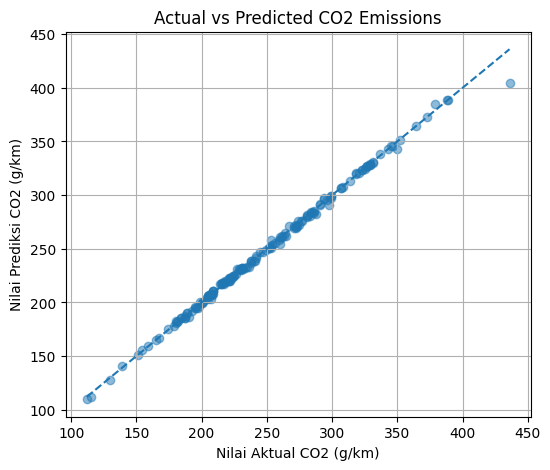


Keterangan:
- Titik yang mendekati garis putus-putus menunjukkan prediksi yang akurat.
- Semakin jauh titik dari garis, semakin besar error prediksi.

## [2] FEATURE IMPORTANCE (FITUR PALING BERPENGARUH)



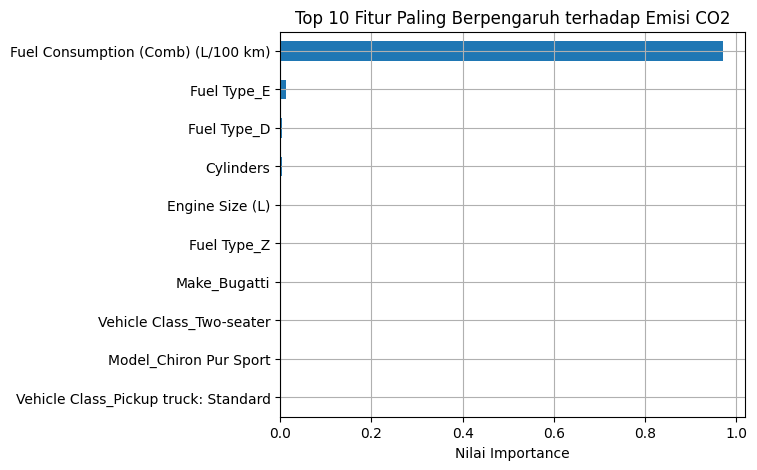


Keterangan:
- Fitur yang berada di posisi paling atas memiliki pengaruh terbesar.
- Semakin besar nilai importance, semakin besar kontribusinya terhadap prediksi.

## [3] ANALISIS ERROR (RESIDUAL PLOT)



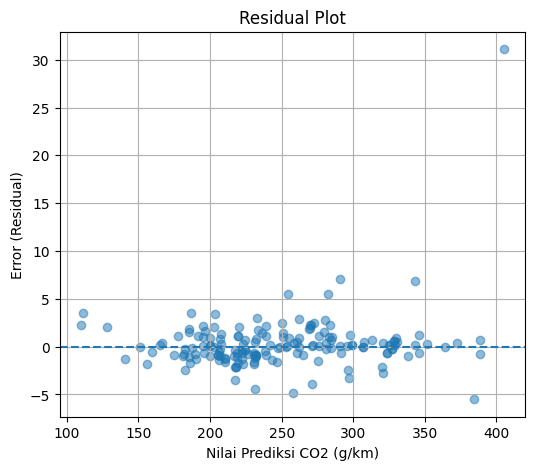


Keterangan:
- Titik yang tersebar acak di sekitar garis 0 menunjukkan model tidak bias.
- Pola tertentu (misalnya melengkung) menandakan model belum optimal.

## [4] INTERPRETASI MODEL

Model memiliki performa yang baik (R² tinggi).


In [11]:
print("\n===== VISUALISASI MODEL =====")

# =====================================================
# 1. ACTUAL VS PREDICTED
# =====================================================
print("\n ## [1] PERBANDINGAN NILAI AKTUAL VS PREDIKSI\n")

plt.figure(figsize=(6,5))

# scatter lebih transparan agar tidak padat
plt.scatter(y_test, y_pred, alpha=0.5)

# garis ideal (prediksi sempurna)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--'
)

plt.xlabel("Nilai Aktual CO2 (g/km)")
plt.ylabel("Nilai Prediksi CO2 (g/km)")
plt.title("Actual vs Predicted CO2 Emissions")

plt.grid(True)
plt.show()

print("\nKeterangan:")
print("- Titik yang mendekati garis putus-putus menunjukkan prediksi yang akurat.")
print("- Semakin jauh titik dari garis, semakin besar error prediksi.\n")


# =====================================================
# 2. FEATURE IMPORTANCE
# =====================================================
print("## [2] FEATURE IMPORTANCE (FITUR PALING BERPENGARUH)\n")

importance = model.feature_importances_
feat_importance = pd.Series(importance, index=feature_columns)

# ambil 10 fitur paling penting
top_features = feat_importance.sort_values(ascending=True).tail(10)

plt.figure(figsize=(6,5))
top_features.plot(kind='barh')

plt.title("Top 10 Fitur Paling Berpengaruh terhadap Emisi CO2")
plt.xlabel("Nilai Importance")

plt.grid(True)
plt.show()

print("\nKeterangan:")
print("- Fitur yang berada di posisi paling atas memiliki pengaruh terbesar.")
print("- Semakin besar nilai importance, semakin besar kontribusinya terhadap prediksi.\n")

# =====================================================
# 3. RESIDUAL PLOT
# =====================================================
print("## [3] ANALISIS ERROR (RESIDUAL PLOT)\n")

residuals = y_test - y_pred

plt.figure(figsize=(6,5))

plt.scatter(y_pred, residuals, alpha=0.5)

# garis nol (error = 0)
plt.axhline(y=0, linestyle='--')

plt.xlabel("Nilai Prediksi CO2 (g/km)")
plt.ylabel("Error (Residual)")
plt.title("Residual Plot")

plt.grid(True)
plt.show()

print("\nKeterangan:")
print("- Titik yang tersebar acak di sekitar garis 0 menunjukkan model tidak bias.")
print("- Pola tertentu (misalnya melengkung) menandakan model belum optimal.\n")


# =====================================================
# 4. INTERPRETASI MODEL
# =====================================================
print("## [4] INTERPRETASI MODEL\n")

r2 = r2_score(y_test, y_pred)

if r2 > 0.8:
    print("Model memiliki performa yang baik (R² tinggi).")
elif r2 > 0.6:
    print("Model cukup baik namun masih bisa ditingkatkan.")
else:
    print("Model kurang baik, perlu perbaikan lebih lanjut.")

## 10. Persiapan Rekomendasi

In [12]:
df_rec = df_encoded.copy()

## 11. Implementasi Input Spesifikasi Kendaraan

In [13]:
# ================= FIX SCROLL JUPYTER =================
display(HTML("""
<style>
.output_area {
    overflow-x: hidden !important;
}
.jp-OutputArea-output {
    overflow-x: hidden !important;
}
</style>
"""))

# ================= DATA =================
target = 'CO2 Emissions (g/km)'

df_raw = df.copy()
df_raw['ID'] = df_raw.index  # ID hanya untuk mapping

# MODEL DATA (TANPA ID)
df_model = pd.get_dummies(df.copy(), drop_first=False)

feature_columns = df_model.columns.drop(target)

scaler = StandardScaler()
scaler.fit(df_model[feature_columns])

# ================= LIMIT =================
engine_min, engine_max = df_raw['Engine Size (L)'].min(), df_raw['Engine Size (L)'].max()
cyl_min, cyl_max = df_raw['Cylinders'].min(), df_raw['Cylinders'].max()
cons_min, cons_max = (
    df_raw['Fuel Consumption (Comb) (L/100 km)'].min(),
    df_raw['Fuel Consumption (Comb) (L/100 km)'].max()
)

# ================= FORM =================
def form_row(label_text, widget):
    widget.layout = widgets.Layout(width='140px')
    return widgets.HBox([
        widgets.Label(value=label_text, layout=widgets.Layout(width='200px')),
        widget
    ])

engine_input = widgets.FloatText(value=2.0)
cyl_input = widgets.IntText(value=4)
cons_input = widgets.FloatText(value=8.5)

fuel_input = widgets.Dropdown(options=fuel_list)
trans_input = widgets.Dropdown(options=transmission_list)

button = widgets.Button(
    description="Prediksi & Rekomendasi",
    button_style='success',
    layout=widgets.Layout(width='360px', margin='20px 0px 10px 0px')
)

output = widgets.Output()

# ================= VALIDATION =================
def validate_input():
    errors = []

    if not (engine_min <= engine_input.value <= engine_max):
        errors.append("Engine tidak valid")
    if not (cyl_min <= cyl_input.value <= cyl_max):
        errors.append("Cylinders tidak valid")
    if not (cons_min <= cons_input.value <= cons_max):
        errors.append("Fuel Consumption tidak valid")

    return errors

# ================= FUNCTION =================
def on_click(b):
    with output:
        clear_output()

        errors = validate_input()
        if errors:
            print("❌ DATA TIDAK VALID")
            for e in errors:
                print("-", e)
            return

        # ================= INPUT USER =================
        user_data = pd.DataFrame(columns=feature_columns)
        user_data.loc[0] = 0

        user_data['Engine Size (L)'] = engine_input.value
        user_data['Cylinders'] = cyl_input.value
        user_data['Fuel Consumption (Comb) (L/100 km)'] = cons_input.value

        fuel_col = f"Fuel Type_{fuel_input.value}"
        trans_col = f"Transmission_{trans_input.value}"

        if fuel_col in user_data.columns:
            user_data[fuel_col] = 1
        if trans_col in user_data.columns:
            user_data[trans_col] = 1

        # ================= PREDIKSI =================
        pred = model.predict(user_data)[0]

        print("===== HASIL PREDIKSI =====")
        print(f"CO2 Emission: {pred:.2f} g/km\n")

        # ================= SIMILARITY =================
        dist = euclidean_distances(
            scaler.transform(user_data),
            scaler.transform(df_model[feature_columns])
        )[0]

        df_model_local = df_model.copy()
        df_model_local['similarity'] = 1 / (1 + dist)

        # TAMBAHKAN ID UNTUK MAPPING
        df_model_local['ID'] = df_raw['ID'].values

        # ================= FILTER =================
        mask = (
            (df_raw['Fuel Type'] == fuel_input.value) &
            (df_raw['Transmission'] == trans_input.value) &
            (df_raw[target] < pred)
        )

        rec = df_model_local[mask].copy()

        if rec.empty:
            print("❌ Tidak ada rekomendasi")
            return

        # ================= RANKING =================
        rec['score'] = (
            0.6 * rec['similarity'] +
            0.4 * (1 - (df_raw.loc[rec.index, target] / pred))
        )

        rec['CO2'] = df_raw.loc[rec.index, target]

        # urutkan berdasarkan emisi terendah
        rec = rec.sort_values(by='CO2', ascending=True).head(10)
        rec_ids = rec['ID']

        # ================= KATEGORI =================
        q1 = rec['score'].quantile(0.33)
        q2 = rec['score'].quantile(0.66)

        def kategori(val):
            if val >= q2:
                return 'Tinggi'
            elif val >= q1:
                return 'Sedang'
            else:
                return 'Rendah'

        # ================= OUTPUT FINAL =================
        hasil = df_raw[df_raw['ID'].isin(rec_ids)][[
            'ID', 'Make', 'Model', 'Vehicle Class', 'Fuel Type', 'Transmission'
        ]].copy()

        # ambil CO2 berdasarkan ID (AMAN)
        hasil[target] = hasil['ID'].map(df_raw.set_index('ID')[target])

        # kategori berdasarkan ranking
        hasil['Tingkat Rekomendasi'] = rec['score'].values

        # sinkronkan urutan sesuai ranking
        hasil = hasil.set_index('ID').loc[rec_ids].reset_index()

        # ubah score jadi label
        hasil['Tingkat Rekomendasi'] = hasil['Tingkat Rekomendasi'].apply(kategori)

        # ================= NOMOR =================
        hasil = hasil.reset_index(drop=True)
        hasil.insert(0, 'No.', hasil.index + 1)

        print("====== TOP 10 REKOMENDASI KENDARAAN ======")

        # ================= WARNA =================
        q1_co2 = hasil[target].quantile(0.33)
        q2_co2 = hasil[target].quantile(0.66)

        def warna_co2(val):
            if val <= q1_co2:
                return 'background-color: #66BB6A'
            elif val <= q2_co2:
                return 'background-color: #FFE066'
            else:
                return 'background-color: #A98274'

        def warna_kategori(val):
            if val == 'Tinggi':
                return 'background-color: #bbdefb'
            elif val == 'Sedang':
                return 'background-color: #e1bee7'
            else:
                return 'background-color: #ffcdd2'

        display(
            hasil.style
            .hide(axis="index")
            .set_table_styles([
                {'selector': 'table', 'props': [('width', '100%'), ('table-layout', 'fixed')]},
                {'selector': 'th', 'props': [('font-size', '12px'), ('text-align', 'center'), ('padding', '4px')]},
                {'selector': 'td', 'props': [('font-size', '12px'), ('text-align', 'center'),
                                            ('white-space', 'normal'), ('word-wrap', 'break-word'), ('padding', '4px')]}
            ])
            .map(warna_co2, subset=[target])
            .map(warna_kategori, subset=['Tingkat Rekomendasi'])
        )

        # ================= KETERANGAN =================
        print("\n===== KETERANGAN WARNA EMISI CO2 =====")

        print("🟢 Tingkat emisi rendah")
        print("🟡 Tingkat emisi sedang")
        print("🟤 Tingkat emisi tinggi")

        print("\n===== KETERANGAN TINGKAT REKOMENDASI =====")

        print("🔵 Tinggi : Sangat direkomendasikan")
        print("🟣 Sedang : Cukup direkomendasikan")
        print("🔴 Rendah : Kurang direkomendasikan")

# ================= EVENT =================
button.on_click(on_click)

ui = widgets.VBox([
    widgets.HTML("<h3>Input Prediksi CO2</h3>"),
    form_row("Engine (L)", engine_input),
    form_row("Cylinders", cyl_input),
    form_row("Fuel Consumption", cons_input),
    widgets.HTML("<h3>Filter</h3>"),
    form_row("Fuel Type", fuel_input),
    form_row("Transmission", trans_input),
    button,
    output
])

display(ui)

## Kesimpulan

- Model mampu memprediksi emisi karbon dioksida (CO₂) berdasarkan input pengguna.
- Sistem memberikan rekomendasi kendaraan dengan emisi lebih rendah yang sesuai berdasarkan input spesifikasi kendaraan dari pengguna.
